In [1]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt
np.set_printoptions(precision=2, suppress=True)

### Dùng camera intrinsic matrix để chiếu điểm 3D biết trước xuống ảnh 2D

#### Tạo các điểm 3D trong world coordinates

In [3]:
# World coordinates
surface_offset = np.array([0, 0, 0.5])
white = np.array([0, 0, 5]) - surface_offset
yellow = np.array([0, 0, 7.5]) - surface_offset
blue = np.array([0, 0, 10]) - surface_offset
green = np.array([2, 0, 5]) - surface_offset
red = np.array([0, -2, 5]) - surface_offset
cyan = np.array([-2, 0, 5]) - surface_offset
pink = np.array([0, 2, 5]) - surface_offset

world_coords = {
    "white": white,
    "yellow": yellow,
    "blue": blue,
    "green": green,
    "red": red,
    "cyan": cyan,
    "pink": pink
}

##### Đọc và hiển thị ảnh gốc

Image size: 1600x900


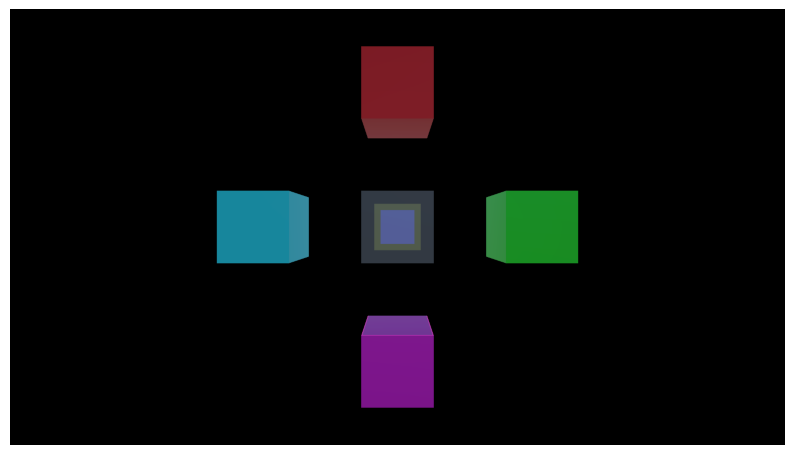

In [4]:
img_left = cv2.imread("data/sim/cam_l.png")
h, w = img_left.shape[:2]
print(f"Image size: {w}x{h}")

plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

#### Ma trận nội tại camera (K)

In [5]:
# Camera intrinsics
fx=671.130
fy=671.130
cx=800.000
cy=450.000

K = np.array([[fx, 0, cx],
              [0, fy, cy],
              [0,  0,  1]])

print(f"Camera intrinsic matrix:\n{K}")

Camera intrinsic matrix:
[[671.13   0.   800.  ]
 [  0.   671.13 450.  ]
 [  0.     0.     1.  ]]


##### Hàm chiếu điểm 3D → 2D 

In [6]:
# project world points to uv // Projective transformation matrix
def project_points(point_3d, K): 
    temp = K @ point_3d     
    #temp = np.linalg.matmul(K, point_3d)
    # u = temp[0] / temp[2]
    # v = temp[1] / temp[2]
    uv = temp[:2] / temp[2]

    return uv

# Iterate pair in world_coors 
uv_points = []
for name, wc in world_coords.items():
    uv = project_points(wc, K)
    uv_points.append(uv)
    print(f"World point: {name} at {wc} -> Image point: {uv}")

World point: white at [0.  0.  4.5] -> Image point: [800. 450.]
World point: yellow at [0. 0. 7.] -> Image point: [800. 450.]
World point: blue at [0.  0.  9.5] -> Image point: [800. 450.]
World point: green at [2.  0.  4.5] -> Image point: [1098.28  450.  ]
World point: red at [ 0.  -2.   4.5] -> Image point: [800.   151.72]
World point: cyan at [-2.   0.   4.5] -> Image point: [501.72 450.  ]
World point: pink at [0.  2.  4.5] -> Image point: [800.   748.28]


##### Vẽ các điểm đã chiếu lên ản

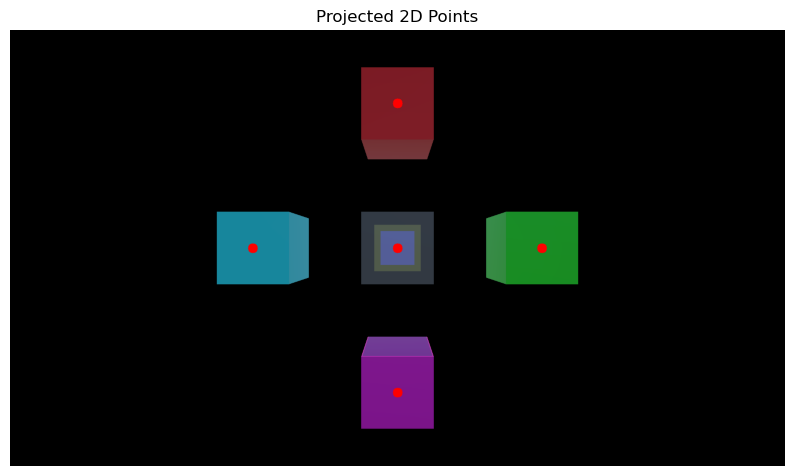

In [7]:
# show projected points on the image
img_copy = img_left.copy()

for uv in uv_points:
    u, v = int(uv[0]), int(uv[1])
    cv2.circle(img_copy, (u, v), 10, (0, 0, 255), -1)


plt.figure(figsize=(10, 8))  
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title("Projected 2D Points")
plt.axis("off")
plt.show()
